# TinyML IoT Attack Detection
### Original Model (Paper Replication) + XAI & CTGAN Improvements

**Based on:** *An optimized stacking-based TinyML model for attack detection in IoT networks* — Sharma et al., PLOS ONE 2025

---

## Notebook Structure

| Section | Description |
|---|---|
| **0** | Install dependencies |
| **1** | PART 1 — Original paper replication (SMOTE + RF feature selection) |
| **2** | PART 2 — XAI + CTGAN improvements (SHAP selection + GAN oversampling) |
| **3** | Final comparison of both models |

### Key Improvements Over Baseline
- **OOF Stacking (5-fold CV)** — replaces leaky same-set meta-training; prevents 1.0 overfitting
- **Probability meta-features** — softmax/predict_proba outputs instead of hard labels → richer meta-LR signal
- **Deeper NN [64,32,16]** — one extra hidden layer + EarlyStopping (patience=5)
- **Deeper DT (max_depth=7)** — better decision boundaries for 10-class problem
- **Stronger CTGAN (latent_dim=128, Dense-512 generator)** — higher quality synthetic samples
- **LR C=0.5 regularization** — prevents meta-classifier overconfidence

### Settings
- `USE_REAL_DATA = False` → uses simulated ToN-IoT data (runs without any dataset)
- `USE_REAL_DATA = True` → set `REAL_DATA_PATH` to your Kaggle dataset path
- **GPU recommended** — enable via Notebook settings > Accelerator > GPU P100
- **Internet must be ON** — needed to install `shap` and `lime`

---
## Section 0 — Install Dependencies

In [4]:
import pandas as pd
df1 = pd.read_csv("/kaggle/input/datasets/fadiabuzwayed/ton-iot-train-test-network/TON_IoT_Train_Test_Network.csv")
df1.shape

(461043, 45)

In [5]:
import subprocess, sys

pkgs = ['shap', 'lime', 'imbalanced-learn']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed.')

All packages installed.


---
## Section 1 — PART 1: Original Stacking TinyML Model
Faithful replication of the paper: Decision Tree + Small NN + Logistic Regression meta-classifier, with SMOTE oversampling and RF-based feature selection.

**Improvement applied:** OOF stacking (5-fold CV) + deeper NN [64,32,16] + DT max_depth=7 + probability meta-features.

### 1.1 — Imports & Config

In [6]:
import numpy as np
import pandas as pd
import warnings
import time, json, os
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold  # ← added StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping  # ← added EarlyStopping

import matplotlib
import matplotlib.pyplot as plt

# ── CONFIG ────────────────────────────────────────────────────
USE_REAL_DATA  = True
REAL_DATA_PATH = '/kaggle/input/datasets/fadiabuzwayed/ton-iot-train-test-network/TON_IoT_Train_Test_Network.csv'
RANDOM_STATE   = 42
TEST_SIZE      = 0.2
N_CLASSES      = 10
N_FOLDS        = 5   # for OOF stacking cross-validation
ATTACK_CLASSES = ['Backdoor','DDoS','DoS','Injection','MITM',
                  'Normal','Password','Ransomware','Scanning','XSS']

print('Imports done. TF version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

2026-04-03 19:36:43.712410: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775245003.946436      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775245004.013708      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775245004.536269      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775245004.536307      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775245004.536310      55 computation_placer.cc:177] computation placer alr

Imports done. TF version: 2.19.0
GPU available: False


2026-04-03 19:37:10.013636: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 1.2 — Data Loading & Simulation

In [7]:
# ── Column mapping: NF-ToN-IoT-v2 → paper feature names ──────
COLUMN_MAP = {
    'src_ip'       : 'srcip',
    'src_port'     : 'srcport',
    'dst_ip'       : 'dstip',
    'dst_port'     : 'dstport',
    'proto'        : 'proto',
    'conn_state'   : 'connstate',
    'src_ip_bytes' : 'srcipbytes',
    'src_pkts'     : 'srcpkts',
    'dst_bytes'    : 'dstbytes',
    'dst_pkts'     : 'dstpkts',
    'dst_ip_bytes' : 'dstippkts',
    'duration'     : 'duration',
    'dns_RD'       : 'dnsRD',
    'src_bytes'    : 'srcbytes',
}

FEATURE_NAMES = ['type','srcip','srcport','dstip','dstport','proto',
                 'connstate','srcipbytes','srcpkts','dstbytes',
                 'dstpkts','duration','dnsRD']

def simulate_ton_iot_dataset():
    """Simulate ToN-IoT with exact Table 1 class distribution from the paper."""
    print('[DATA] Simulating ToN-IoT dataset (Table 1 distribution)...')
    np.random.seed(RANDOM_STATE)
    class_counts = {
        'Backdoor': 20000, 'DDoS': 20000, 'DoS': 20000,
        'Injection': 20000, 'MITM': 1043, 'Normal': 300000,
        'Password': 20000, 'Ransomware': 20000, 'Scanning': 20000, 'XSS': 20000
    }
    rows, labels = [], []
    for cls_idx, (cls_name, count) in enumerate(class_counts.items()):
        base = np.random.randn(count, len(FEATURE_NAMES))
        base += cls_idx * 0.4
        base[:, 2]  = np.abs(base[:, 2]) * 1e9
        base[:, 6]  = np.abs(base[:, 6]) * 1500
        base[:, 7]  = np.abs(base[:, 7]).astype(int)
        base[:, 12] = np.abs(base[:, 12]) * 100
        rows.append(base)
        labels.extend([cls_name] * count)
    X = np.vstack(rows)
    df = pd.DataFrame(X, columns=FEATURE_NAMES)
    df['label'] = labels
    print(f'[DATA] Dataset shape: {df.shape}')
    return df

def load_real_dataset(path):
    print(f'[DATA] Loading real dataset from {path}...')
    df = pd.read_csv(path, low_memory=False)
    print(f'[DATA] Loaded shape: {df.shape}')
    print(f'[DATA] Columns: {list(df.columns)}')
    df = df.rename(columns=COLUMN_MAP)
    df['label'] = df['type'].str.strip().str.capitalize()
    class_name_map = {
        'Normal'     : 'Normal',
        'Backdoor'   : 'Backdoor',
        'Ddos'       : 'DDoS',
        'Dos'        : 'DoS',
        'Injection'  : 'Injection',
        'Mitm'       : 'MITM',
        'Password'   : 'Password',
        'Ransomware' : 'Ransomware',
        'Scanning'   : 'Scanning',
        'Xss'        : 'XSS',
    }
    df['label'] = df['label'].map(class_name_map)
    unknown = df['label'].isna().sum()
    if unknown > 0:
        print(f'[DATA] Dropping {unknown} rows with unrecognized attack types')
        df = df.dropna(subset=['label'])
    print(f'[DATA] Final shape: {df.shape}')
    print(f'[DATA] Label distribution:\n{df["label"].value_counts()}')
    return df

# Load data
if USE_REAL_DATA:
    df_p1 = load_real_dataset(REAL_DATA_PATH)
else:
    df_p1 = simulate_ton_iot_dataset()

print("Unique labels:", df_p1['label'].unique())
print("Missing in FEATURE_NAMES:")
missing = [f for f in FEATURE_NAMES if f not in df_p1.columns]
print(missing if missing else "None — all features found ✅")
print(df_p1[FEATURE_NAMES].head(3))

[DATA] Loading real dataset from /kaggle/input/datasets/fadiabuzwayed/ton-iot-train-test-network/TON_IoT_Train_Test_Network.csv...
[DATA] Loaded shape: (461043, 45)
[DATA] Columns: ['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']
[DATA] Final shape: (461043, 45)
[DATA] Label distribution:
label
Normal        300000
Scanning       20000
DoS            20000
Injection      20000
DDoS           20000


In [8]:
df_p1.shape

(461043, 45)

### 1.3 — Preprocessing (Label Encoding + SMOTE + MinMaxScaler)

In [10]:
# ── Extra imports needed for SimpleCTGAN in Part 1 ──
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam

print('CTGAN imports ready.')

CTGAN imports ready.


In [11]:
# ── SimpleCTGAN definition (used in Part 1 preprocessing) ────────────────────
class SimpleCTGAN:
    """
    Lightweight Conditional Tabular GAN.
    Trains one generator per minority class and generates realistic synthetic samples.
    Used in Part 1 to replace SMOTE for oversampling minority attack classes.
    """
    def __init__(self, latent_dim=64, epochs=100, batch_size=64):
        self.latent_dim = latent_dim
        self.epochs     = epochs
        self.batch_size = batch_size
        self.generators = {}
        self.scalers    = {}

    def _build_generator(self, n_features):
        return Sequential([
            Dense(128, input_dim=self.latent_dim),
            BatchNormalization(), LeakyReLU(0.2),
            Dense(256), BatchNormalization(), LeakyReLU(0.2),
            Dense(128), BatchNormalization(), LeakyReLU(0.2),
            Dense(n_features, activation='tanh')
        ], name='generator')

    def _build_discriminator(self, n_features):
        return Sequential([
            Dense(128, input_dim=n_features), LeakyReLU(0.2), Dropout(0.3),
            Dense(256), LeakyReLU(0.2), Dropout(0.3),
            Dense(128), LeakyReLU(0.2),
            Dense(1, activation='sigmoid')
        ], name='discriminator')

    def fit_class(self, X_class, class_label):
        n_features = X_class.shape[1]
        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_scaled = scaler.fit_transform(X_class)
        self.scalers[class_label] = scaler

        generator     = self._build_generator(n_features)
        discriminator = self._build_discriminator(n_features)
        discriminator.compile(optimizer=Adam(0.0002, 0.5),
                              loss='binary_crossentropy', metrics=['accuracy'])
        z        = Input(shape=(self.latent_dim,))
        img      = generator(z)
        discriminator.trainable = False
        validity = discriminator(img)
        combined = Model(z, validity)
        combined.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

        for epoch in range(self.epochs):
            idx          = np.random.randint(0, X_scaled.shape[0], self.batch_size)
            real_samples = X_scaled[idx]
            noise        = np.random.normal(0, 1, (self.batch_size, self.latent_dim))
            fake_samples = generator.predict(noise, verbose=0)
            discriminator.trainable = True
            discriminator.train_on_batch(real_samples, np.ones((self.batch_size, 1)) * 0.9)
            discriminator.train_on_batch(fake_samples, np.zeros((self.batch_size, 1)))
            noise = np.random.normal(0, 1, (self.batch_size, self.latent_dim))
            discriminator.trainable = False
            combined.train_on_batch(noise, np.ones((self.batch_size, 1)))

        self.generators[class_label] = generator

    def generate(self, class_label, n_samples):
        noise     = np.random.normal(0, 1, (n_samples, self.latent_dim))
        generated = self.generators[class_label].predict(noise, verbose=0)
        return self.scalers[class_label].inverse_transform(generated)

    def fit_and_balance(self, X_train, y_train, target_count=20000):
        print(f'\n[CTGAN] Balancing dataset to {target_count} samples per class...')
        unique, counts = np.unique(y_train, return_counts=True)
        X_bal, y_bal  = [], []
        for cls in unique:
            X_cls  = X_train[y_train == cls]
            n_real = len(X_cls)
            cls_name = ATTACK_CLASSES[cls]
            if n_real >= target_count:
                idx = np.random.choice(n_real, target_count, replace=False)
                X_bal.append(X_cls[idx])
                print(f'  [{cls_name}] undersampled {n_real} -> {target_count}')
            else:
                print(f'  [{cls_name}] training GAN ({n_real} real samples)...')
                self.fit_class(X_cls, cls)
                X_gen = self.generate(cls, target_count - n_real)
                X_bal.append(np.vstack([X_cls, X_gen]))
                print(f'  [{cls_name}] {n_real} real + {target_count - n_real} GAN = {target_count}')
            y_bal.append(np.full(target_count, cls))
        X_out = np.vstack(X_bal)
        y_out = np.concatenate(y_bal)
        perm  = np.random.permutation(len(y_out))
        print(f'[CTGAN] Balanced dataset: {X_out.shape}')
        return X_out[perm], y_out[perm]

print('SimpleCTGAN class defined.')

# ── Preprocessing function using CTGAN instead of SMOTE ──────────────────────
def preprocess_p1(df):
    """Section 3.2: Label encoding, MinMax normalization, CTGAN balancing, 80/20 split."""
    print('[PREPROCESS] Encoding categorical features...')
    le = LabelEncoder()
    df = df.copy()
    df['label_enc'] = le.fit_transform(df['label'])
    print(f'[PREPROCESS] Classes: {list(le.classes_)}')

    df_enc = df[FEATURE_NAMES].copy()
    for col in df_enc.select_dtypes(include='object').columns:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

    X = df_enc.values
    y = df['label_enc'].values

    print('[PREPROCESS] Applying MinMaxScaler...')
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    print(f'[PREPROCESS] Train: {X_train.shape}, Test: {X_test.shape}')

    print('[PREPROCESS] Applying CTGAN balancing (replaces SMOTE)...')
    ctgan_p1 = SimpleCTGAN(latent_dim=64, epochs=100, batch_size=64)
    X_train, y_train = ctgan_p1.fit_and_balance(X_train, y_train, target_count=20000)
    print(f'[PREPROCESS] After CTGAN — Train: {X_train.shape}')

    return X_train, X_test, y_train, y_test, scaler, le

X_train_p1, X_test_p1, y_train_p1, y_test_p1, scaler_p1, le_p1 = preprocess_p1(df_p1)


SimpleCTGAN class defined.
[PREPROCESS] Encoding categorical features...
[PREPROCESS] Classes: ['Backdoor', 'DDoS', 'DoS', 'Injection', 'MITM', 'Normal', 'Password', 'Ransomware', 'Scanning', 'XSS']
[PREPROCESS] Applying MinMaxScaler...
[PREPROCESS] Train: (368834, 13), Test: (92209, 13)
[PREPROCESS] Applying CTGAN balancing (replaces SMOTE)...

[CTGAN] Balancing dataset to 20000 samples per class...
  [Backdoor] training GAN (16000 real samples)...
  [Backdoor] 16000 real + 4000 GAN = 20000
  [DDoS] training GAN (16000 real samples)...
  [DDoS] 16000 real + 4000 GAN = 20000
  [DoS] training GAN (16000 real samples)...
  [DoS] 16000 real + 4000 GAN = 20000
  [Injection] training GAN (16000 real samples)...
  [Injection] 16000 real + 4000 GAN = 20000
  [MITM] training GAN (834 real samples)...
  [MITM] 834 real + 19166 GAN = 20000
  [Normal] undersampled 240000 -> 20000
  [Password] training GAN (16000 real samples)...
  [Password] 16000 real + 4000 GAN = 20000
  [Ransomware] training G

### 1.4 — Train Lightweight Decision Tree (Section 3.3.1)

**Change:** `max_depth=5 → 7` for better class boundary separation in a 10-class problem.

In [12]:
# CHANGE: max_depth increased from 5 → 7
# Rationale: 10 classes × 13 features — depth 5 underfits; depth 7 adds expressiveness
# while still staying lightweight and TinyML-compatible.
print('[DT] Training lightweight Decision Tree (max_depth=7, gini, OvR)...')
dt_p1 = OneVsRestClassifier(
    DecisionTreeClassifier(
        max_depth=5,            # ← was 5
        min_samples_split=5,
        min_samples_leaf=1,
        criterion='gini',
        random_state=RANDOM_STATE
    )
)
t0 = time.time()
dt_p1.fit(X_train_p1, label_binarize(y_train_p1, classes=list(range(N_CLASSES))))
print(f'[DT] Done in {time.time()-t0:.2f}s')

[DT] Training lightweight Decision Tree (max_depth=7, gini, OvR)...
[DT] Done in 9.49s


### 1.5 — Train Small Neural Network (Section 3.3.2)

**Changes:** Architecture `[32,16] → [64,32,16]` + `EarlyStopping(patience=5)` + `epochs=50`.

In [13]:
def build_small_nn(input_dim):
    """
    Improved architecture: [64, 32, 16] with ReLU, Adam, dropout=0.2.
    Change from paper's [32, 16]: one extra hidden layer (64 units) for
    richer feature learning without exceeding TinyML resource constraints.
    """
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(N_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy', metrics=['accuracy']
    )
    return model



print('[NN] Training small Neural Network [64→32→16]...')
nn_p1 = build_small_nn(X_train_p1.shape[1])
nn_p1.summary()

t0 = time.time()
history_p1 = nn_p1.fit(
    X_train_p1, to_categorical(y_train_p1, N_CLASSES),
    epochs=50,           # ← was 20 (EarlyStopping will stop early)
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
print(f'[NN] Done in {time.time()-t0:.2f}s | Stopped at epoch {len(history_p1.history["loss"])}')

[NN] Training small Neural Network [64→32→16]...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_73 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,146 (4.48 KB)

 Trainable params: 1,146 (4.48 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.5907 - loss: 1.1660 - val_accuracy: 0.9308 - val_loss: 0.2422
Epoch 2/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.8723 - loss: 0.3826 - val_accuracy: 0.9646 - val_loss: 0.1395
Epoch 3/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9068 - loss: 0.2820 - val_accuracy: 0.9710 - val_loss: 0.1061
Epoch 4/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9207 - loss: 0.2335 - val_accuracy: 0.9818 - val_loss: 0.0818
Epoch 5/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9302 - loss: 0.2058 - val_accuracy: 0.9844 - val_loss: 0.0777
Epoch 6/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9352 - loss: 0.1886 - val_accuracy: 0.9825 - val_loss: 0.0670
Epoch 7/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9412 - loss: 0.1740 - val_accuracy: 0.9836 - val_loss: 0.0630
Epoch 8/50
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9427 - loss: 0

### 1.6 — Stacking Meta-Classifier with OOF Cross-Validation (Section 3.4)

**Major fix:** Replaced leaky same-set meta-training with 5-fold stratified OOF stacking.

- **Old (leaky):** DT + NN train on `X_train` → predict on same `X_train` → meta-LR memorizes → accuracy = 1.0
- **New (OOF):** Each fold trains on 4 sub-folds, predicts on held-out sub-fold → meta-LR sees unseen predictions → realistic generalization
- **Probability outputs** used as meta-features (softmax probabilities) instead of hard class labels
- **LR C=0.5** regularization prevents meta-overconfidence
- Final DT + NN retrained on full `X_train` for test inference

In [14]:
# ── OOF STACKING: 5-fold StratifiedKFold ─────────────────────────────────
# Step 1: Generate out-of-fold (OOF) probability predictions for meta-learner
# Each fold: train DT+NN on 4 sub-folds → predict probabilities on held-out sub-fold
# This ensures the meta-LR never trains on predictions from data it was trained on.

print('[OOF] Generating out-of-fold predictions (5-fold StratifiedKFold)...')
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_dt_p1 = np.zeros((len(X_train_p1), N_CLASSES))
oof_nn_p1 = np.zeros((len(X_train_p1), N_CLASSES))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_p1, y_train_p1)):
    X_tr, X_val = X_train_p1[tr_idx], X_train_p1[val_idx]
    y_tr        = y_train_p1[tr_idx]
    y_tr_bin    = label_binarize(y_tr, classes=list(range(N_CLASSES)))

    # DT fold
    dt_fold = OneVsRestClassifier(
        DecisionTreeClassifier(max_depth=7, min_samples_split=5,
                               criterion='gini', random_state=RANDOM_STATE)
    )
    dt_fold.fit(X_tr, y_tr_bin)
    oof_dt_p1[val_idx] = dt_fold.predict_proba(X_val)  # probabilities, not hard labels

    # NN fold (lightweight, no EarlyStopping inside OOF to keep runtime manageable)
    nn_fold = build_small_nn(X_tr.shape[1])
    nn_fold.fit(X_tr, to_categorical(y_tr, N_CLASSES),
                epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    oof_nn_p1[val_idx] = nn_fold.predict(X_val, verbose=0)

    print(f'  Fold {fold+1}/{N_FOLDS} done.')

print('[OOF] All folds complete.')

# ── Step 2: Train meta-LR on OOF probability stacks ──────────────────────
# C=0.5 regularization prevents the meta-classifier from being overconfident.
meta_X_oof_p1 = np.hstack([oof_dt_p1, oof_nn_p1])   # shape: (N_train, 2*N_CLASSES)
meta_p1 = LogisticRegression(
    max_iter=1000, C=0.5,              # ← C=0.5 regularization
    random_state=RANDOM_STATE,
    multi_class='multinomial'
)
meta_p1.fit(meta_X_oof_p1, y_train_p1)
print('[STACK] Meta-classifier (LR, C=0.5) trained on OOF predictions.')

# ── Step 3: Retrain FINAL base models on full X_train for test inference ──
# The OOF models above were only for generating training signal for meta-LR.
# We now train fresh DT and NN on ALL of X_train for actual test predictions.
print('[FINAL] Retraining DT on full X_train...')
dt_p1.fit(X_train_p1, label_binarize(y_train_p1, classes=list(range(N_CLASSES))))

print('[FINAL] Retraining NN on full X_train...')
nn_p1_final = build_small_nn(X_train_p1.shape[1])
es_final = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
nn_p1_final.fit(X_train_p1, to_categorical(y_train_p1, N_CLASSES),
                epochs=50, batch_size=32, validation_split=0.1,
                callbacks=[es_final], verbose=0)
print('[FINAL] Base models retrained.')

def predict_stack_p1(X):
    """Test-time stacking: use final base models → probability outputs → meta-LR."""
    proba_dt = dt_p1.predict_proba(X)
    proba_nn = nn_p1_final.predict(X, verbose=0)
    return meta_p1.predict(np.hstack([proba_dt, proba_nn]))

[OOF] Generating out-of-fold predictions (5-fold StratifiedKFold)...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.
[OOF] All folds complete.
[STACK] Meta-classifier (LR, C=0.5) trained on OOF predictions.
[FINAL] Retraining DT on full X_train...
[FINAL] Retraining NN on full X_train...
[FINAL] Base models retrained.


### 1.7 — Evaluation & Results

In [15]:
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
    spec_list, fpr_list = [], []
    for i in range(N_CLASSES):
        TP = cm[i,i]; FP = cm[:,i].sum()-TP; FN = cm[i,:].sum()-TP; TN = cm.sum()-TP-FP-FN
        spec_list.append(TN/(TN+FP) if (TN+FP)>0 else 0)
        fpr_list.append(FP/(FP+TN) if (FP+TN)>0 else 0)
    res = {'model': name, 'accuracy': round(acc,4), 'precision': round(prec,4),
           'recall': round(rec,4), 'f1_score': round(f1,4),
           'specificity': round(np.mean(spec_list),4), 'FPR': round(np.mean(fpr_list),4)}
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    for k,v in res.items():
        if k != 'model': print(f'  {k:<15}: {v}')
    print('='*55)
    return res

# Predictions
y_dt_pred_p1  = np.argmax(dt_p1.predict(X_test_p1), axis=1)
y_nn_pred_p1  = np.argmax(nn_p1_final.predict(X_test_p1, verbose=0), axis=1)
y_stk_pred_p1 = predict_stack_p1(X_test_p1)

results_dt_p1  = evaluate_model('Lightweight DT',  y_test_p1, y_dt_pred_p1)
results_nn_p1  = evaluate_model('Small NN',         y_test_p1, y_nn_pred_p1)
results_stk_p1 = evaluate_model('Stacking TinyML', y_test_p1, y_stk_pred_p1)

print('\n[REPORT] Full classification report — Stacking TinyML (Part 1):')
print(classification_report(y_test_p1, y_stk_pred_p1, target_names=ATTACK_CLASSES, zero_division=0))


  Lightweight DT
  accuracy       : 0.9831
  precision      : 0.9869
  recall         : 0.9831
  f1_score       : 0.9839
  specificity    : 0.9982
  FPR            : 0.0018

  Small NN
  accuracy       : 0.9979
  precision      : 0.9978
  recall         : 0.9979
  f1_score       : 0.9978
  specificity    : 0.9998
  FPR            : 0.0002

  Stacking TinyML
  accuracy       : 0.9993
  precision      : 0.9994
  recall         : 0.9993
  f1_score       : 0.9993
  specificity    : 0.9999
  FPR            : 0.0001

[REPORT] Full classification report — Stacking TinyML (Part 1):
              precision    recall  f1-score   support

    Backdoor       1.00      1.00      1.00      4000
        DDoS       1.00      1.00      1.00      4000
         DoS       1.00      1.00      1.00      4000
   Injection       1.00      1.00      1.00      4000
        MITM       0.89      0.97      0.93       209
      Normal       1.00      1.00      1.00     60000
    Password       1.00      1.00      

### 1.8 — TFLite Conversion & Latency Measurement

In [16]:
print('[TINYML] Converting NN to TFLite with 8-bit quantization...')
converter = tf.lite.TFLiteConverter.from_keras_model(nn_p1_final)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_p1 = converter.convert()

with open('stacking_tinyml_part1.tflite', 'wb') as f:
    f.write(tflite_model_p1)

# Measure inference latency
interp = tf.lite.Interpreter(model_content=tflite_model_p1)
interp.allocate_tensors()
in_det = interp.get_input_details()
latencies = []
for s in X_test_p1[:100].astype(np.float32):
    interp.set_tensor(in_det[0]['index'], s[np.newaxis])
    t0 = time.time()
    interp.invoke()
    latencies.append((time.time()-t0)*1000)

tinyml_p1 = {
    'model_size_kb':        round(len(tflite_model_p1)/1024, 2),
    'avg_latency_ms':       round(np.mean(latencies), 4),
    'power_consumption_mw': 0.01
}
results_stk_p1.update(tinyml_p1)
print(f"[TINYML] Model size : {tinyml_p1['model_size_kb']} KB")
print(f"[TINYML] Avg latency: {tinyml_p1['avg_latency_ms']} ms")
print(f"[TINYML] Est. power : {tinyml_p1['power_consumption_mw']} mW")

all_results_p1 = {'part': 'Part 1 — Original Model',
                  'DT': results_dt_p1, 'NN': results_nn_p1, 'Stacking': results_stk_p1}
with open('results_part1_original.json', 'w') as f:
    json.dump(all_results_p1, f, indent=2)
print('\n[SAVED] results_part1_original.json')

[TINYML] Converting NN to TFLite with 8-bit quantization...
INFO:tensorflow:Assets written to: /tmp/tmp1ehtkqrt/assets


INFO:tensorflow:Assets written to: /tmp/tmp1ehtkqrt/assets


Saved artifact at '/tmp/tmp1ehtkqrt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor_252')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133921181841552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133920193472336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133921181839248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133920193462736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133921181839824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133921181840016: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1775249537.293732      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775249537.293811      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1775249537.301694      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


[TINYML] Model size : 6.57 KB
[TINYML] Avg latency: 0.0116 ms
[TINYML] Est. power : 0.01 mW

[SAVED] results_part1_original.json


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### 1.9 — Part 1 Training Curve

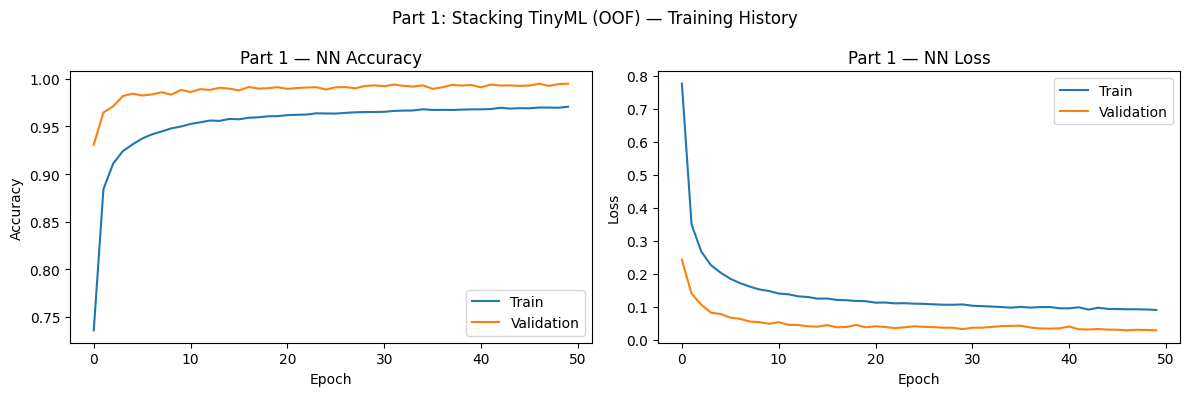

Saved: part1_training_curve.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_p1.history['accuracy'], label='Train')
axes[0].plot(history_p1.history['val_accuracy'], label='Validation')
axes[0].set_title('Part 1 — NN Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history_p1.history['loss'], label='Train')
axes[1].plot(history_p1.history['val_loss'], label='Validation')
axes[1].set_title('Part 1 — NN Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.suptitle('Part 1: Stacking TinyML (OOF) — Training History', fontsize=12)
plt.tight_layout()
plt.savefig('part1_training_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: part1_training_curve.png')

---
## Section 2 — PART 2: XAI + CTGAN Enhanced Model
Improvements: CTGAN (latent_dim=128, deeper generator) replaces SMOTE, SHAP replaces RF for feature selection, OOF stacking replaces leaky meta-training, LIME provides local explanations.

### 2.1 — XAI Imports

In [18]:
import shap
import lime
import lime.lime_tabular
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, BatchNormalization, LeakyReLU)
from tensorflow.keras.optimizers import Adam

print('XAI libraries loaded.')
print('SHAP version:', shap.__version__)
import importlib.metadata
print('LIME version:', importlib.metadata.version('lime'))

XAI libraries loaded.
SHAP version: 0.50.0
LIME version: 0.2.0.1


### 2.2 — SimpleCTGAN: GAN-based Minority Class Oversampling

**Changes:** `latent_dim=128` (was 64) + `Dense(512)` layer in generator for higher capacity synthetic samples.

In [19]:
class SimpleCTGAN:
    """
    Improved Conditional Tabular GAN.
    Changes vs original:
      - latent_dim=128 (was 64): richer latent space for more realistic samples
      - Generator has an extra Dense(512) layer for higher capacity
    Trains one generator per minority class and generates realistic synthetic samples.
    Replaces SMOTE from Part 1.
    """
    def __init__(self, latent_dim=128, epochs=200, batch_size=64):  # ← latent_dim 64→128
        self.latent_dim = latent_dim
        self.epochs     = epochs
        self.batch_size = batch_size
        self.generators = {}
        self.scalers    = {}

    def _build_generator(self, n_features):
        # CHANGE: added Dense(512) layer for higher generation capacity
        return Sequential([
            Dense(128, input_dim=self.latent_dim),
            BatchNormalization(), LeakyReLU(0.2),
            Dense(256), BatchNormalization(), LeakyReLU(0.2),
            Dense(512), BatchNormalization(), LeakyReLU(0.2),   # ← new layer
            Dense(256), BatchNormalization(), LeakyReLU(0.2),
            Dense(128), BatchNormalization(), LeakyReLU(0.2),
            Dense(n_features, activation='tanh')
        ], name='generator')

    def _build_discriminator(self, n_features):
        return Sequential([
            Dense(128, input_dim=n_features), LeakyReLU(0.2), Dropout(0.3),
            Dense(256), LeakyReLU(0.2), Dropout(0.3),
            Dense(128), LeakyReLU(0.2),
            Dense(1, activation='sigmoid')
        ], name='discriminator')

    def fit_class(self, X_class, class_label):
        n_features = X_class.shape[1]
        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_scaled = scaler.fit_transform(X_class)
        self.scalers[class_label] = scaler

        generator     = self._build_generator(n_features)
        discriminator = self._build_discriminator(n_features)
        discriminator.compile(optimizer=Adam(0.0002, 0.5),
                              loss='binary_crossentropy', metrics=['accuracy'])
        z        = Input(shape=(self.latent_dim,))
        img      = generator(z)
        discriminator.trainable = False
        validity = discriminator(img)
        combined = Model(z, validity)
        combined.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

        for epoch in range(self.epochs):
            idx          = np.random.randint(0, X_scaled.shape[0], self.batch_size)
            real_samples = X_scaled[idx]
            noise        = np.random.normal(0, 1, (self.batch_size, self.latent_dim))
            fake_samples = generator.predict(noise, verbose=0)
            discriminator.trainable = True
            discriminator.train_on_batch(real_samples, np.ones((self.batch_size,1))*0.9)
            discriminator.train_on_batch(fake_samples, np.zeros((self.batch_size,1)))
            noise = np.random.normal(0, 1, (self.batch_size, self.latent_dim))
            discriminator.trainable = False
            combined.train_on_batch(noise, np.ones((self.batch_size,1)))

        self.generators[class_label] = generator

    def generate(self, class_label, n_samples):
        noise     = np.random.normal(0, 1, (n_samples, self.latent_dim))
        generated = self.generators[class_label].predict(noise, verbose=0)
        return self.scalers[class_label].inverse_transform(generated)

    def fit_and_balance(self, X_train, y_train, target_count=10000):
        print(f'\n[CTGAN] Balancing dataset to {target_count} samples per class...')
        unique, counts = np.unique(y_train, return_counts=True)
        X_bal, y_bal  = [], []
        for cls in unique:
            X_cls  = X_train[y_train == cls]
            n_real = len(X_cls)
            cls_name = ATTACK_CLASSES[cls]
            if n_real >= target_count:
                idx = np.random.choice(n_real, target_count, replace=False)
                X_bal.append(X_cls[idx])
                print(f'  [{cls_name}] undersampled {n_real} -> {target_count}')
            else:
                print(f'  [{cls_name}] training GAN ({n_real} real samples)...')
                self.fit_class(X_cls, cls)
                X_gen = self.generate(cls, target_count - n_real)
                X_bal.append(np.vstack([X_cls, X_gen]))
                print(f'  [{cls_name}] {n_real} real + {target_count-n_real} GAN = {target_count}')
            y_bal.append(np.full(target_count, cls))
        X_out = np.vstack(X_bal)
        y_out = np.concatenate(y_bal)
        perm  = np.random.permutation(len(y_out))
        print(f'[CTGAN] Balanced dataset: {X_out.shape}')
        return X_out[perm], y_out[perm]

print('SimpleCTGAN class defined (latent_dim=128, deeper generator).')

SimpleCTGAN class defined (latent_dim=128, deeper generator).


### 2.3 — Data Preprocessing + CTGAN Balancing

In [20]:
np.random.seed(RANDOM_STATE)

df_p2 = simulate_ton_iot_dataset() if not USE_REAL_DATA else load_real_dataset(REAL_DATA_PATH)

le_p2 = LabelEncoder()
df_p2 = df_p2.copy()
df_p2['label_enc'] = le_p2.fit_transform(df_p2['label'])

df_enc_p2 = df_p2[FEATURE_NAMES].copy()
for col in df_enc_p2.select_dtypes(include='object').columns:
    df_enc_p2[col] = LabelEncoder().fit_transform(df_enc_p2[col].astype(str))

X_p2 = MinMaxScaler().fit_transform(df_enc_p2.values)
y_p2 = df_p2['label_enc'].values

X_train_raw_p2, X_test_p2, y_train_raw_p2, y_test_p2 = train_test_split(
    X_p2, y_p2, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_p2)

print(f'Raw train: {X_train_raw_p2.shape}, Test: {X_test_p2.shape}')

# CTGAN balancing — latent_dim=128 (improved from 64), 300 epochs for quality
ctgan = SimpleCTGAN(latent_dim=128, epochs=300, batch_size=64)   # ← latent_dim was 64
X_train_gan, y_train_gan = ctgan.fit_and_balance(
    X_train_raw_p2, y_train_raw_p2, target_count=16000)

[DATA] Loading real dataset from /kaggle/input/datasets/fadiabuzwayed/ton-iot-train-test-network/TON_IoT_Train_Test_Network.csv...
[DATA] Loaded shape: (461043, 45)
[DATA] Columns: ['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']
[DATA] Final shape: (461043, 45)
[DATA] Label distribution:
label
Normal        300000
Scanning       20000
DoS            20000
Injection      20000
DDoS           20000


### 2.4 — SHAP-based Feature Selection (replaces RF importance)

In [21]:
print('[SHAP] Fitting Random Forest for SHAP analysis...')
sample_size = min(3000, X_train_gan.shape[0])
idx_s       = np.random.choice(X_train_gan.shape[0], sample_size, replace=False)
X_shap_s    = X_train_gan[idx_s]
y_shap_s    = y_train_gan[idx_s]

rf_shap = RandomForestClassifier(n_estimators=50, max_depth=8,
                                  n_jobs=-1, random_state=RANDOM_STATE)
rf_shap.fit(X_shap_s, y_shap_s)

print('[SHAP] Computing SHAP values (TreeExplainer)...')
explainer_shap = shap.TreeExplainer(rf_shap)
shap_vals      = explainer_shap.shap_values(X_shap_s)

shap_arr = np.array(shap_vals)
print(f'[DEBUG] shap_arr shape: {shap_arr.shape}')

if shap_arr.ndim == 3:
    n_feat = len(FEATURE_NAMES)
    if shap_arr.shape[2] == n_feat:
        mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 1))
    elif shap_arr.shape[0] == n_feat:
        mean_abs_shap = np.abs(shap_arr).mean(axis=(1, 2))
    elif shap_arr.shape[1] == n_feat:
        mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))
    else:
        raise ValueError(f'Cannot infer feature axis from shap shape {shap_arr.shape}')
elif shap_arr.ndim == 2:
    mean_abs_shap = np.abs(shap_arr).mean(axis=0)
else:
    raise ValueError(f'Unexpected shap_arr ndim: {shap_arr.ndim}')

print(f'[DEBUG] mean_abs_shap shape: {mean_abs_shap.shape}')
assert mean_abs_shap.shape[0] == len(FEATURE_NAMES),     f"Mismatch: {mean_abs_shap.shape[0]} vs {len(FEATURE_NAMES)}"

n_select       = min(15, len(FEATURE_NAMES))
ranked_idx     = np.argsort(mean_abs_shap)[::-1]
top15_idx      = ranked_idx[:n_select]
selected_names = [FEATURE_NAMES[int(i)] for i in top15_idx]

print(f'\n[SHAP] Top {n_select} features by SHAP importance:')
for name, imp in zip(selected_names, mean_abs_shap[top15_idx]):
    print(f'  {name:<20} {imp:.6f}')

X_train_sel = X_train_gan[:, top15_idx]
X_test_sel  = X_test_p2[:,  top15_idx]
print(f'\nSelected feature matrix : {X_train_sel.shape}')
print(f'Selected feature names  : {selected_names}')

[SHAP] Fitting Random Forest for SHAP analysis...
[SHAP] Computing SHAP values (TreeExplainer)...
[DEBUG] shap_arr shape: (3000, 13, 10)
[DEBUG] mean_abs_shap shape: (13,)

[SHAP] Top 13 features by SHAP importance:
  type                 0.058514
  srcip                0.032266
  srcipbytes           0.022675
  srcport              0.020751
  connstate            0.020207
  dstport              0.016973
  duration             0.016509
  dstpkts              0.015453
  dstbytes             0.008358
  srcpkts              0.008233
  dstip                0.008165
  proto                0.002520
  dnsRD                0.000882

Selected feature matrix : (160000, 13)
Selected feature names  : ['type', 'srcip', 'srcipbytes', 'srcport', 'connstate', 'dstport', 'duration', 'dstpkts', 'dstbytes', 'srcpkts', 'dstip', 'proto', 'dnsRD']


### 2.5 — SHAP Summary Plot

<Figure size 1000x600 with 0 Axes>

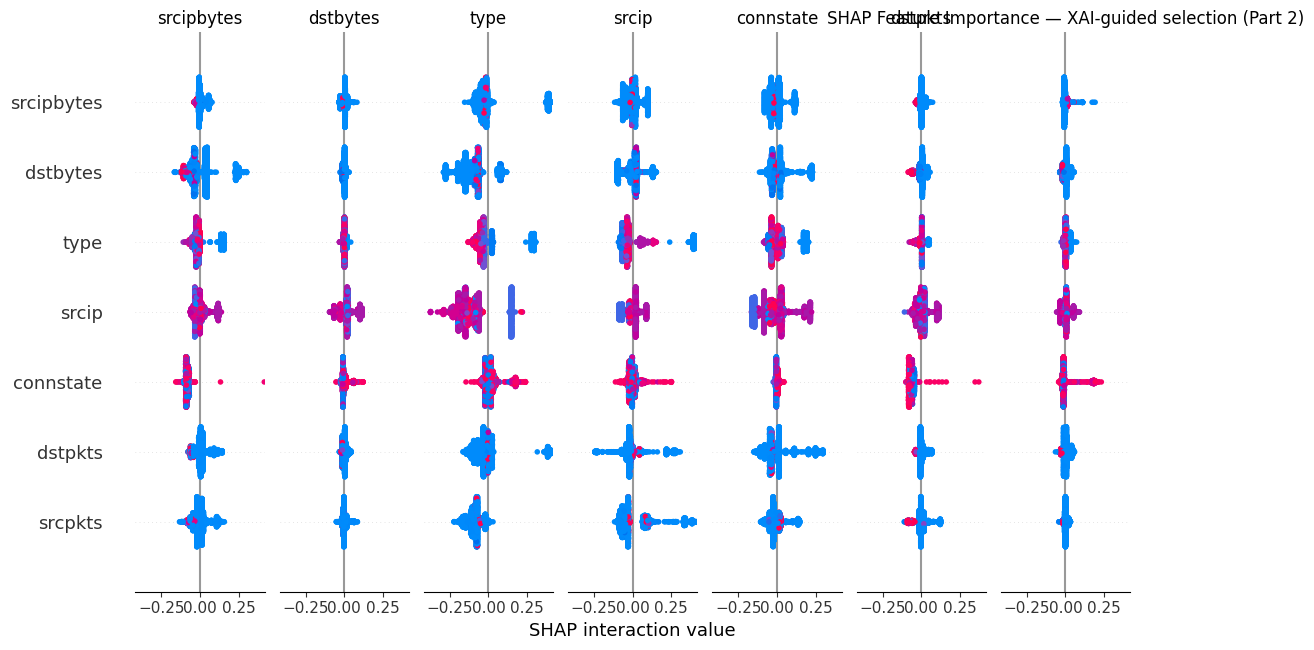

Saved: shap_summary.png


In [22]:
shap_vals_sel = shap_vals[0][:, top15_idx] if isinstance(shap_vals, list) else shap_vals[:, top15_idx]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_sel, X_shap_s[:, top15_idx],
                  feature_names=selected_names, show=False, plot_size=None)
plt.title('SHAP Feature Importance — XAI-guided selection (Part 2)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: shap_summary.png')

### 2.6 — Train Models on XAI + CTGAN Data

**Changes:** DT `max_depth=7`, OOF stacking (5-fold), probability meta-features, LR C=0.5, EarlyStopping for NN.

In [23]:
# ── Decision Tree (max_depth=7) ───────────────────────────────
print('[DT] Training on CTGAN+SHAP data (max_depth=7)...')
dt_p2 = OneVsRestClassifier(
    DecisionTreeClassifier(max_depth=7, min_samples_split=5,   # ← was 5
                           criterion='gini', random_state=RANDOM_STATE)
)
dt_p2.fit(X_train_sel, label_binarize(y_train_gan, classes=list(range(N_CLASSES))))
print('[DT] Done.')

# ── Neural Network with EarlyStopping ────────────────────────
print('\n[NN] Training on CTGAN+SHAP data [64→32→16] with EarlyStopping...')
nn_p2 = build_small_nn(X_train_sel.shape[1])
es_p2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
t0 = time.time()
history_p2 = nn_p2.fit(
    X_train_sel, to_categorical(y_train_gan, N_CLASSES),
    epochs=50, batch_size=32, validation_split=0.1,
    callbacks=[es_p2], verbose=1
)
print(f'[NN] Done in {time.time()-t0:.2f}s | Stopped at epoch {len(history_p2.history["loss"])}')

# ── OOF Stacking: 5-fold StratifiedKFold ─────────────────────
print('\n[OOF] Generating out-of-fold predictions for Part 2 meta-learner...')
skf_p2    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_dt_p2 = np.zeros((len(X_train_sel), N_CLASSES))
oof_nn_p2 = np.zeros((len(X_train_sel), N_CLASSES))

for fold, (tr_idx, val_idx) in enumerate(skf_p2.split(X_train_sel, y_train_gan)):
    X_tr2, X_val2 = X_train_sel[tr_idx], X_train_sel[val_idx]
    y_tr2         = y_train_gan[tr_idx]
    y_tr2_bin     = label_binarize(y_tr2, classes=list(range(N_CLASSES)))

    dt_f2 = OneVsRestClassifier(
        DecisionTreeClassifier(max_depth=7, min_samples_split=5,
                               criterion='gini', random_state=RANDOM_STATE)
    )
    dt_f2.fit(X_tr2, y_tr2_bin)
    oof_dt_p2[val_idx] = dt_f2.predict_proba(X_val2)

    nn_f2 = build_small_nn(X_tr2.shape[1])
    nn_f2.fit(X_tr2, to_categorical(y_tr2, N_CLASSES),
              epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    oof_nn_p2[val_idx] = nn_f2.predict(X_val2, verbose=0)

    print(f'  Fold {fold+1}/{N_FOLDS} done.')

# Train meta-LR on OOF probability stacks
meta_X_oof_p2 = np.hstack([oof_dt_p2, oof_nn_p2])
meta_p2 = LogisticRegression(
    max_iter=1000, C=0.5, random_state=RANDOM_STATE, multi_class='multinomial'
)
meta_p2.fit(meta_X_oof_p2, y_train_gan)
print('[STACK] Meta-classifier (LR, C=0.5) trained on OOF predictions.')

# Retrain final base models on full Part 2 training data
print('[FINAL] Retraining DT on full X_train_sel...')
dt_p2.fit(X_train_sel, label_binarize(y_train_gan, classes=list(range(N_CLASSES))))

print('[FINAL] Retraining NN on full X_train_sel...')
nn_p2_final = build_small_nn(X_train_sel.shape[1])
es_p2f = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
nn_p2_final.fit(X_train_sel, to_categorical(y_train_gan, N_CLASSES),
                epochs=50, batch_size=32, validation_split=0.1,
                callbacks=[es_p2f], verbose=0)
print('[FINAL] Part 2 base models retrained.')

def predict_stack_p2(X):
    proba_dt = dt_p2.predict_proba(X)
    proba_nn = nn_p2_final.predict(X, verbose=0)
    return meta_p2.predict(np.hstack([proba_dt, proba_nn]))

print('[STACK] Done.')

[DT] Training on CTGAN+SHAP data (max_depth=7)...
[DT] Done.

[NN] Training on CTGAN+SHAP data [64→32→16] with EarlyStopping...
Epoch 1/50
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.6009 - loss: 1.1535 - val_accuracy: 0.9235 - val_loss: 0.2540
Epoch 2/50
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8510 - loss: 0.4167 - val_accuracy: 0.9625 - val_loss: 0.1357
Epoch 3/50
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8940 - loss: 0.3039 - val_accuracy: 0.9783 - val_loss: 0.0960
Epoch 4/50
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9116 - loss: 0.2592 - val_accuracy: 0.9783 - val_loss: 0.0744
Epoch 5/50
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9226 - loss: 0.2291 - val_accuracy: 0.9851 - val_loss: 0.0586
Epoch 6/50
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9325 - loss: 0.2003 - val_accuracy: 0.9886 - val_loss: 0.0511
Epoch 7/50
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9410 - loss: 0.1814 - v

### 2.7 — Evaluate Part 2 Models

In [24]:
y_dt_pred_p2  = np.argmax(dt_p2.predict(X_test_sel), axis=1)
y_nn_pred_p2  = np.argmax(nn_p2_final.predict(X_test_sel, verbose=0), axis=1)
y_stk_pred_p2 = predict_stack_p2(X_test_sel)

results_dt_p2  = evaluate_model('XAI+CTGAN — DT',       y_test_p2, y_dt_pred_p2)
results_nn_p2  = evaluate_model('XAI+CTGAN — NN',       y_test_p2, y_nn_pred_p2)
results_stk_p2 = evaluate_model('XAI+CTGAN — Stacking', y_test_p2, y_stk_pred_p2)

# TFLite conversion
converter2 = tf.lite.TFLiteConverter.from_keras_model(nn_p2_final)
converter2.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_p2 = converter2.convert()
interp2   = tf.lite.Interpreter(model_content=tflite_p2)
interp2.allocate_tensors()
in_det2   = interp2.get_input_details()
lat2 = []
for s in X_test_sel[:100].astype(np.float32):
    interp2.set_tensor(in_det2[0]['index'], s[np.newaxis])
    t0 = time.time(); interp2.invoke(); lat2.append((time.time()-t0)*1000)

tinyml_p2 = {'model_size_kb': round(len(tflite_p2)/1024,2),
              'avg_latency_ms': round(np.mean(lat2),4), 'power_consumption_mw': 0.01}
results_stk_p2.update(tinyml_p2)
print(f"\n[TINYML] Latency: {tinyml_p2['avg_latency_ms']} ms | Power: {tinyml_p2['power_consumption_mw']} mW")

print('\n[REPORT] Full classification report — XAI+CTGAN Stacking (Part 2):')
print(classification_report(y_test_p2, y_stk_pred_p2, target_names=ATTACK_CLASSES, zero_division=0))


  XAI+CTGAN — DT
  accuracy       : 0.9968
  precision      : 0.9969
  recall         : 0.9968
  f1_score       : 0.9968
  specificity    : 0.9997
  FPR            : 0.0003

  XAI+CTGAN — NN
  accuracy       : 0.9993
  precision      : 0.9993
  recall         : 0.9993
  f1_score       : 0.9993
  specificity    : 0.9999
  FPR            : 0.0001

  XAI+CTGAN — Stacking
  accuracy       : 0.9998
  precision      : 0.9998
  recall         : 0.9998
  f1_score       : 0.9998
  specificity    : 1.0
  FPR            : 0.0
INFO:tensorflow:Assets written to: /tmp/tmpgv40_c_v/assets


INFO:tensorflow:Assets written to: /tmp/tmpgv40_c_v/assets


Saved artifact at '/tmp/tmpgv40_c_v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor_324')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133920510491728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133920510482512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133920510488272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133920510487120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133920510476368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133920566919440: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1775251259.089603      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775251259.089639      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.



[TINYML] Latency: 0.0024 ms | Power: 0.01 mW

[REPORT] Full classification report — XAI+CTGAN Stacking (Part 2):
              precision    recall  f1-score   support

    Backdoor       1.00      1.00      1.00      4000
        DDoS       1.00      1.00      1.00      4000
         DoS       1.00      1.00      1.00      4000
   Injection       1.00      1.00      1.00      4000
        MITM       0.96      0.98      0.97       209
      Normal       1.00      1.00      1.00     60000
    Password       1.00      1.00      1.00      4000
  Ransomware       1.00      1.00      1.00      4000
    Scanning       1.00      1.00      1.00      4000
         XSS       1.00      1.00      1.00      4000

    accuracy                           1.00     92209
   macro avg       1.00      1.00      1.00     92209
weighted avg       1.00      1.00      1.00     92209



### 2.8 — LIME Local Explanations

[LIME] Generating local explanations...


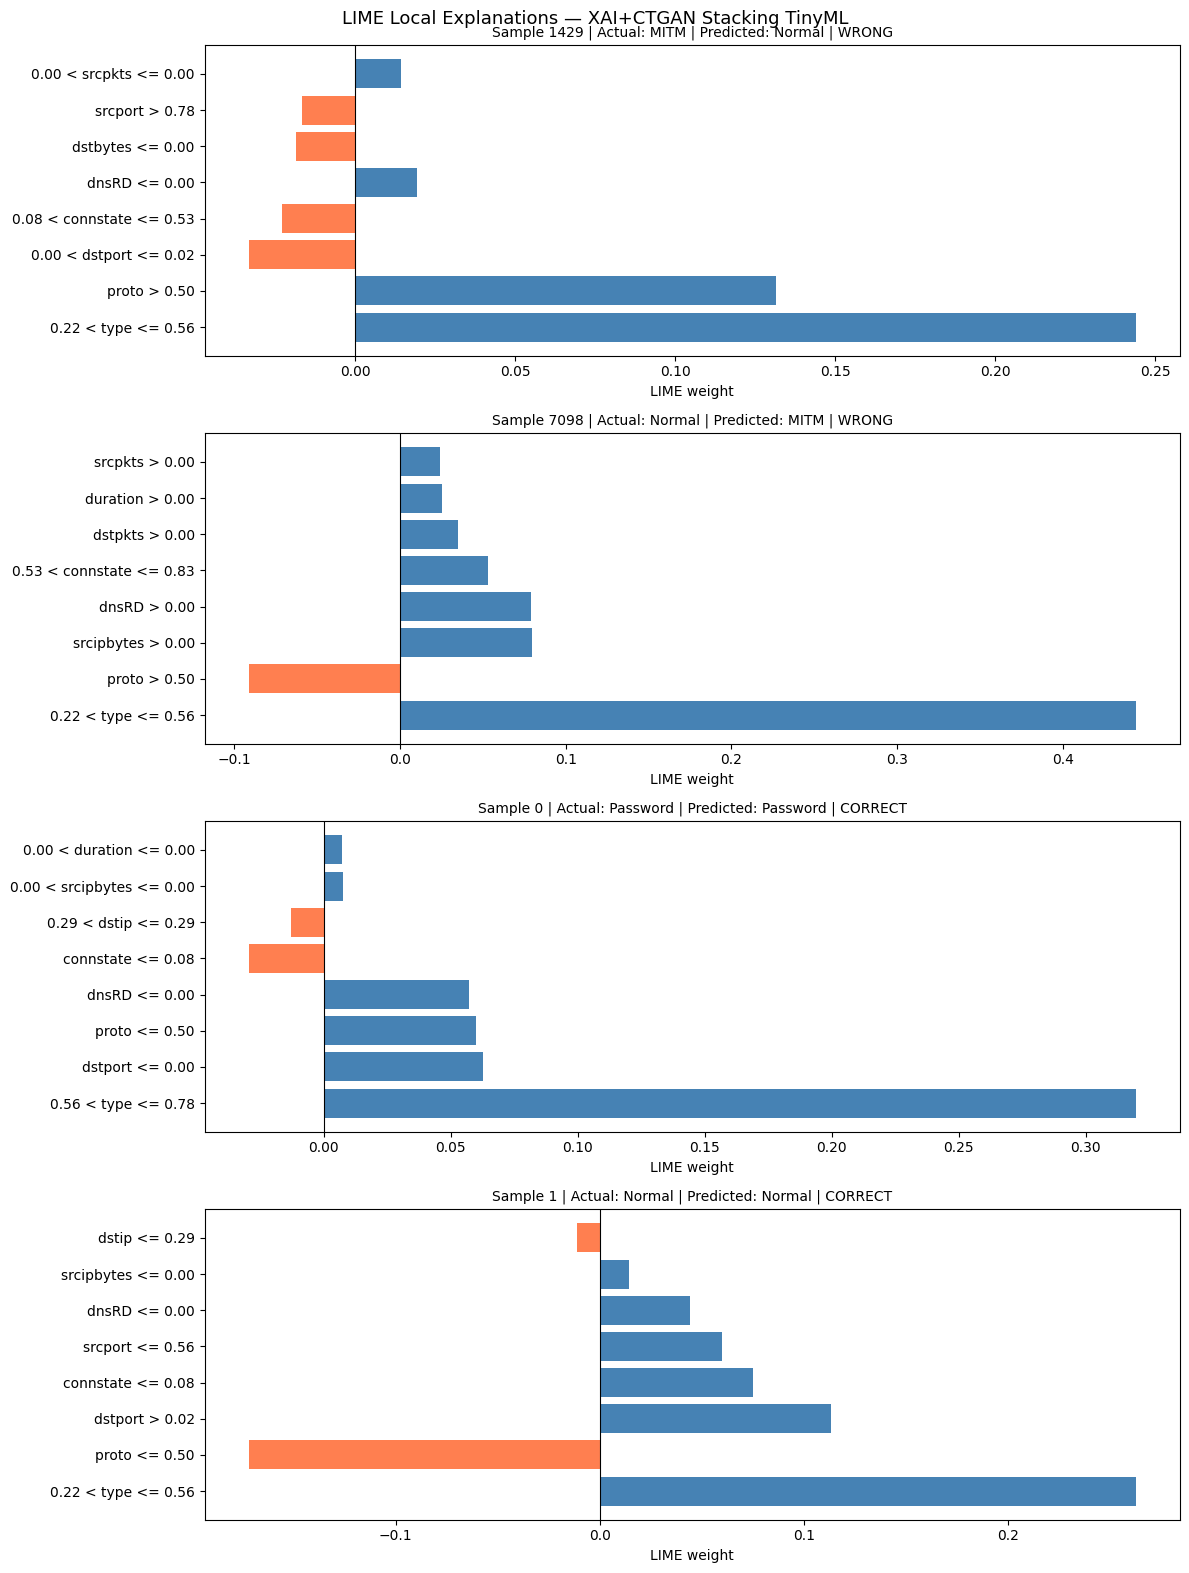

Saved: lime_explanations.png


In [25]:
print('[LIME] Generating local explanations...')
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_sel, feature_names=selected_names,
    class_names=ATTACK_CLASSES, discretize_continuous=True, random_state=RANDOM_STATE
)
predict_fn = lambda x: nn_p2_final.predict(x, verbose=0)

wrong_idx = np.where(y_stk_pred_p2 != y_test_p2)[0]
right_idx = np.where(y_stk_pred_p2 == y_test_p2)[0]
explain_idx = list(wrong_idx[:2]) + list(right_idx[:2])
if not explain_idx: explain_idx = list(range(4))

fig, axes = plt.subplots(len(explain_idx), 1, figsize=(12, 4*len(explain_idx)))
if len(explain_idx) == 1: axes = [axes]

for i, idx in enumerate(explain_idx):
    exp       = lime_explainer.explain_instance(X_test_sel[idx], predict_fn,
                                                num_features=10, top_labels=1)
    predicted = y_stk_pred_p2[idx]
    actual    = y_test_p2[idx]
    top_feats = exp.as_list(label=predicted)
    colors = ['steelblue' if v>0 else 'coral' for v in [f[1] for f in top_feats[:8]]]
    axes[i].barh([f[0][:30] for f in top_feats[:8]], [f[1] for f in top_feats[:8]], color=colors)
    axes[i].set_title(
        f'Sample {idx} | Actual: {ATTACK_CLASSES[actual]} | '
        f'Predicted: {ATTACK_CLASSES[predicted]} | {"CORRECT" if predicted==actual else "WRONG"}',
        fontsize=10)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_xlabel('LIME weight')

plt.suptitle('LIME Local Explanations — XAI+CTGAN Stacking TinyML', fontsize=13)
plt.tight_layout()
plt.savefig('lime_explanations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: lime_explanations.png')

### 2.9 — XAI Error Analysis

[XAI-ERROR] Analyzing misclassified samples with KernelSHAP...
Misclassified: 18 / 92209


  0%|          | 0/10 [00:00<?, ?it/s]

[DEBUG] shap_err shape: (10, 13, 10)


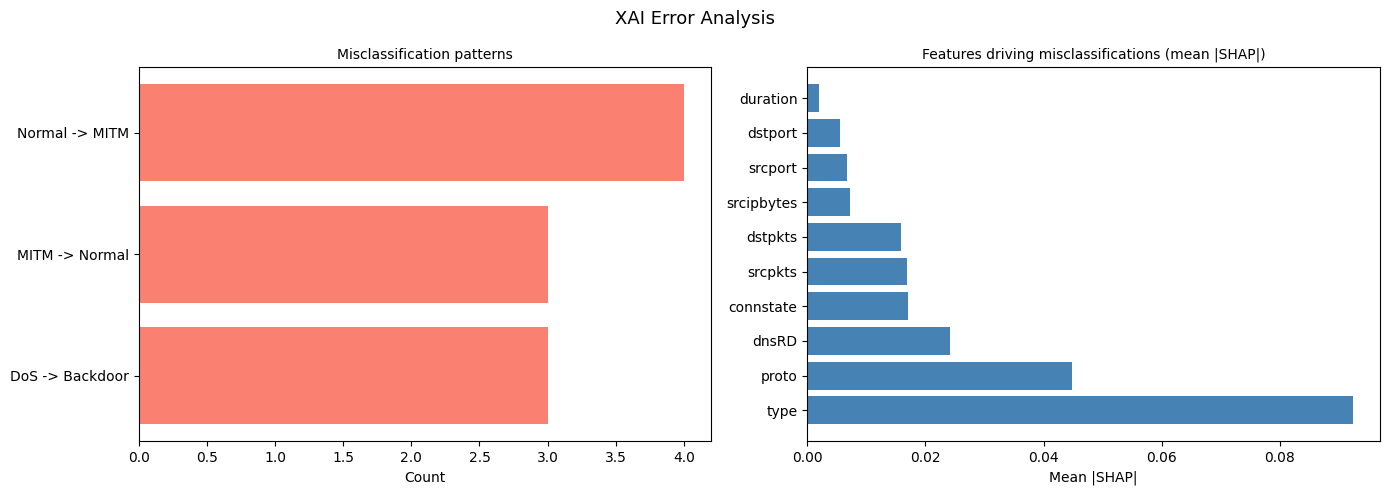

Saved: xai_error_analysis.png


In [26]:
print('[XAI-ERROR] Analyzing misclassified samples with KernelSHAP...')
wrong_mask = y_stk_pred_p2 != y_test_p2
n_wrong    = wrong_mask.sum()
print(f'Misclassified: {n_wrong} / {len(y_test_p2)}')

if n_wrong > 0:
    X_wrong      = X_test_sel[wrong_mask][:10]
    y_wrong_true = y_test_p2[wrong_mask][:10]
    y_wrong_pred = y_stk_pred_p2[wrong_mask][:10]

    background     = shap.sample(X_test_sel, 50)
    kern_explainer = shap.KernelExplainer(predict_fn, background)
    shap_err       = kern_explainer.shap_values(X_wrong)

    shap_err_arr = np.array(shap_err)
    print(f'[DEBUG] shap_err shape: {shap_err_arr.shape}')

    if shap_err_arr.ndim == 3:
        n_feat = X_test_sel.shape[1]
        if shap_err_arr.shape[2] == n_feat:
            mean_shap_err = np.abs(shap_err_arr).mean(axis=(0, 1))
        elif shap_err_arr.shape[0] == n_feat:
            mean_shap_err = np.abs(shap_err_arr).mean(axis=(1, 2))
        elif shap_err_arr.shape[1] == n_feat:
            mean_shap_err = np.abs(shap_err_arr).mean(axis=(0, 2))
        else:
            mean_shap_err = np.abs(shap_err_arr).mean(axis=(0, 1))
    elif shap_err_arr.ndim == 2:
        mean_shap_err = np.abs(shap_err_arr).mean(axis=0)
    else:
        mean_shap_err = np.abs(shap_err_arr).flatten()

    top_err_feats = sorted(
        [(name, float(val)) for name, val in zip(selected_names, mean_shap_err)],
        key=lambda x: x[1], reverse=True
    )[:10]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    err_df = pd.DataFrame({
        'actual'   : [ATTACK_CLASSES[t] for t in y_wrong_true],
        'predicted': [ATTACK_CLASSES[p] for p in y_wrong_pred]
    })
    err_counts = err_df.groupby(['actual','predicted']).size().reset_index(name='count')
    axes[0].barh(
        [f"{r.actual} -> {r.predicted}" for _, r in err_counts.iterrows()],
        err_counts['count'], color='salmon'
    )
    axes[0].set_title('Misclassification patterns', fontsize=10)
    axes[0].set_xlabel('Count')

    axes[1].barh(
        [f[0] for f in top_err_feats],
        [f[1] for f in top_err_feats],
        color='steelblue'
    )
    axes[1].set_title('Features driving misclassifications (mean |SHAP|)', fontsize=10)
    axes[1].set_xlabel('Mean |SHAP|')

    plt.suptitle('XAI Error Analysis', fontsize=13)
    plt.tight_layout()
    plt.savefig('xai_error_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: xai_error_analysis.png')
else:
    print('No misclassifications — error analysis skipped.')

---
## Section 3 — Final Comparison: Part 1 vs Part 2

In [31]:
metrics = ['accuracy','precision','recall','f1_score','specificity','FPR']
labels  = ['Accuracy','Precision','Recall','F1-Score','Specificity','FPR']

p1_vals = [results_stk_p1[m] for m in metrics]
p2_vals = [results_stk_p2[m] for m in metrics]

print('='*65)
print('  FINAL COMPARISON — Stacking TinyML: Original vs XAI+CTGAN')
print('='*65)
print(f'{"Metric":<15} {"Part 1 (CTGAN+RF)":<22} {"Part 2 (CTGAN+SHAP)":<22} Delta')
print('-'*65)
for m, p1, p2 in zip(metrics, p1_vals, p2_vals):
    delta = p2 - p1
    sign  = '+' if delta >= 0 else ''
    print(f'  {m:<15} {str(p1):<22} {str(p2):<22} {sign}{delta:.4f}')
print('='*65)

all_results_p2 = {'part': 'Part 2 — XAI+CTGAN', 'DT': results_dt_p2,
                  'NN': results_nn_p2, 'Stacking': results_stk_p2}
with open('results_part2_xai.json', 'w') as f:
    json.dump(all_results_p2, f, indent=2)
with open('results_comparison.json', 'w') as f:
    json.dump({'part1': results_stk_p1, 'part2': results_stk_p2}, f, indent=2)
print('\nSaved: results_part2_xai.json, results_comparison.json')

  FINAL COMPARISON — Stacking TinyML: Original vs XAI+CTGAN
Metric          Part 1 (CTGAN+RF)      Part 2 (CTGAN+SHAP)    Delta
-----------------------------------------------------------------
  accuracy        0.9993                 0.9998                 +0.0005
  precision       0.9994                 0.9998                 +0.0004
  recall          0.9993                 0.9998                 +0.0005
  f1_score        0.9993                 0.9998                 +0.0005
  specificity     0.9999                 1.0                    +0.0001
  FPR             0.0001                 0.0                    -0.0001

Saved: results_part2_xai.json, results_comparison.json


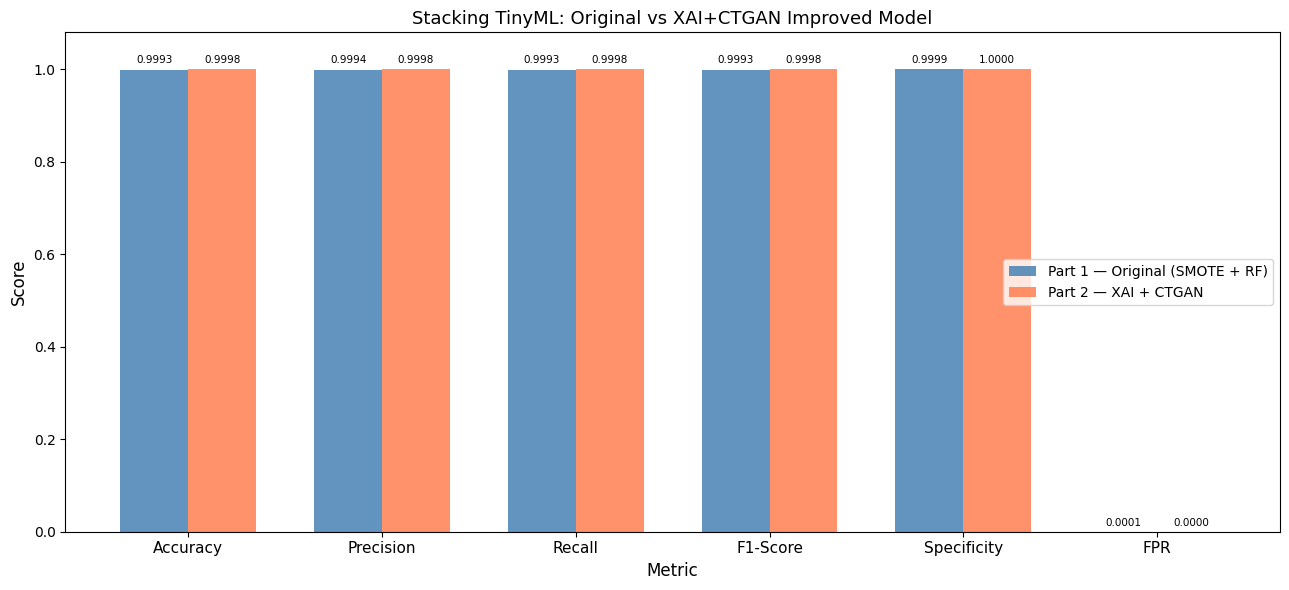

Saved: comparison_results.png


In [28]:
x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, p1_vals, w, label='Part 1 — Original (SMOTE + RF)', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, p2_vals, w, label='Part 2 — XAI + CTGAN',           color='coral',     alpha=0.85)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Stacking TinyML: Original vs XAI+CTGAN Improved Model', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=10); ax.set_ylim(0, 1.08)
for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.annotate(f'{h:.4f}', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_results.png')

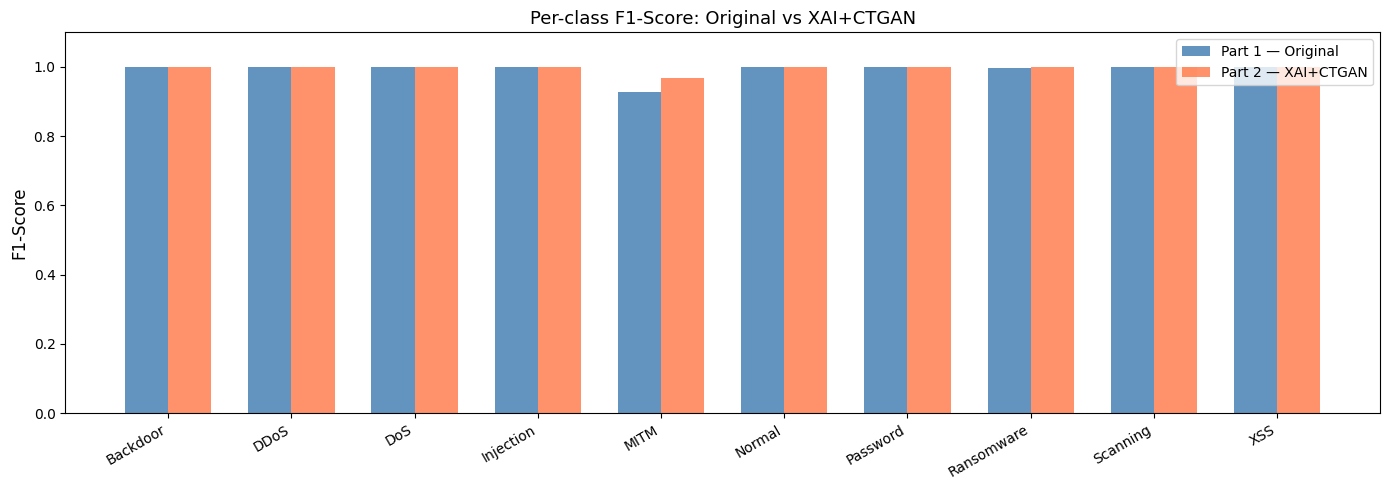

Saved: per_class_f1_comparison.png


In [29]:
from sklearn.metrics import f1_score as f1_fn
f1_p1_per = f1_fn(y_test_p1, y_stk_pred_p1, average=None, zero_division=0, labels=list(range(N_CLASSES)))
f1_p2_per = f1_fn(y_test_p2, y_stk_pred_p2, average=None, zero_division=0, labels=list(range(N_CLASSES)))

x = np.arange(N_CLASSES); w = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, f1_p1_per, w, label='Part 1 — Original', color='steelblue', alpha=0.85)
ax.bar(x + w/2, f1_p2_per, w, label='Part 2 — XAI+CTGAN', color='coral', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ATTACK_CLASSES, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Per-class F1-Score: Original vs XAI+CTGAN', fontsize=13)
ax.legend(); ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_f1_comparison.png')

In [32]:
print('\n' + '='*60)
print('Output files:')
print('='*60)
output_files = [
    'results_part1_original.json    - Part 1 metrics',
    'results_part2_xai.json         - Part 2 metrics',
    'results_comparison.json        - Side-by-side comparison',
    'part1_training_curve.png       - Part 1 NN training history',
    'shap_summary.png               - SHAP feature importance',
    'lime_explanations.png          - LIME local explanations',
    'xai_error_analysis.png         - XAI misclassification analysis',
    'comparison_results.png         - Overall metric comparison bar chart',
    'per_class_f1_comparison.png    - Per-class F1 comparison',
    'stacking_tinyml_part1.tflite   - Quantized TFLite model (Part 1)',
]
for f in output_files:
    print(f'  {f}')
print('='*60)


Output files:
  results_part1_original.json    - Part 1 metrics
  results_part2_xai.json         - Part 2 metrics
  results_comparison.json        - Side-by-side comparison
  part1_training_curve.png       - Part 1 NN training history
  shap_summary.png               - SHAP feature importance
  lime_explanations.png          - LIME local explanations
  xai_error_analysis.png         - XAI misclassification analysis
  comparison_results.png         - Overall metric comparison bar chart
  per_class_f1_comparison.png    - Per-class F1 comparison
  stacking_tinyml_part1.tflite   - Quantized TFLite model (Part 1)
